# Homework 3 

Pratham Mehta

Networks in Biology

### Power Law Function



In [1]:
import numpy as np


def power_law(
    n: int, minval: int, maxval: int, alpha: float, seed: int | None = None
) -> np.ndarray:
    """
    Generates a power law distribution of random integers.

    Parameters
    ----------
    n : int
        The number of random integers to generate.
    minval : int
        The minimum value of the random integers.
    maxval : int
        The maximum value of the random integers.
    alpha : float
        The exponent of the power law distribution.
    seed : int, optional
        The seed value for the random number generator.

    Returns
    -------
    numpy.ndarray
        An array of random integers following a power law distribution.
    """
    if seed is not None:
        np.random.seed(seed)
    u = np.random.random(n)

    if alpha == -1:
        # Special case for alpha = -1 to avoid division by zero
        return np.round(
            np.exp(
                np.log(minval - 0.5) + u * (np.log(maxval + 0.5) - np.log(minval - 0.5))
            )
        ).astype(int)
    else:
        # General case
        a = (minval - 0.5) ** (1 + alpha)
        b = (maxval + 0.5) ** (1 + alpha)
        return np.round((a + u * (b - a)) ** (1 / (1 + alpha))).astype(int)

## Problem 1B - Configruation Model and Comparisons

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# --- Configuration Model Function ---
def configuration_model(degrees, return_graph=False):
    degrees = np.array(degrees)

    ## safety check; 
    assert degrees.sum() % 2 == 0, "Sum of degrees must be even"
    
    # Expand degree sequence into list of nodes
    nodes = np.repeat(np.arange(len(degrees)), degrees)
    
    # Shuffle nodes and pair consecutive nodes to form edges
    np.random.shuffle(nodes)
    edges = list(zip(nodes[::2], nodes[1::2]))
    
    if return_graph:
        G = nx.MultiGraph()
        G.add_edges_from(edges)
        return G
    return edges



### Problem 1c: Power Law Distribution 

In [3]:
# --- Part (c): Generate degree sequence ---
N = 1000
deg_seq = power_law(N, minval=1, maxval=N-1, alpha=-2.5)

# Ensure sum of degrees is even
if deg_seq.sum() % 2 != 0:
    deg_seq[np.random.randint(N)] += 1

# --- Check self-loops and multi-edges over 1000 realizations ---
self_loops = []
multi_edges = []

for _ in range(1000):
    G_sim = configuration_model(deg_seq, return_graph=True)
    
    # Count self-loops
    num_self_loops = sum(1 for u, v in G_sim.edges() if u == v)
    
    # Count multi-edges (edges with multiplicity > 1)
    num_multi_edges = sum(1 for u, v in G_sim.edges() if G_sim.number_of_edges(u, v) > 1)
    
    total_edges = G_sim.number_of_edges()
    
    self_loops.append(num_self_loops / total_edges)
    multi_edges.append(num_multi_edges / total_edges)

print("Avg fraction self-loops:", np.mean(self_loops))
print("Avg fraction multi-edges:", np.mean(multi_edges))




Avg fraction self-loops: 0.005420673076923078
Avg fraction multi-edges: 0.024091346153846154


### 1d: Compare to Budapest Connectome 

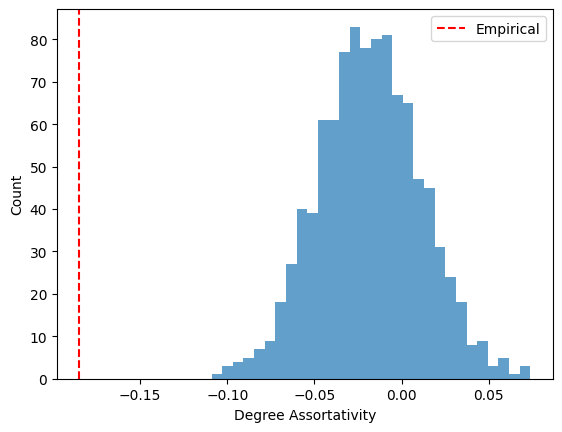

In [6]:
# --- Part (d): Budapest connectome ---
# G already loaded: G = nx.MultiGraph(edgelist_budapest)
import polars as pl

df = pl.read_csv("connectome.csv", separator=";")
edgelist_budapest = df[["id node1", "id node2"]].rows()
G = nx.MultiGraph()
G.add_edges_from(edgelist_budapest)

deg_seq_budapest = [d for n, d in G.degree()]

assortativity_real = nx.degree_assortativity_coefficient(G)
assortativities = []

for _ in range(1000):
    G_sim = configuration_model(deg_seq_budapest, return_graph=True)
    assortativities.append(nx.degree_assortativity_coefficient(G_sim))

plt.hist(assortativities, bins=30, alpha=0.7)
plt.axvline(assortativity_real, color='red', linestyle='dashed', label='Empirical')
plt.xlabel("Degree Assortativity")
plt.ylabel("Count")
plt.legend()
plt.show()


## Question 2: Medici Family 

### Problem 2a: Four centralities + ranked table

In [ ]:
import networkx as nx
import pandas as pd

G_flor = nx.florentine_families_graph()  # built-in dataset

deg_c = nx.degree_centrality(G_flor)
harm_c = nx.harmonic_centrality(G_flor)  # uses distances; robust with disconnected pieces
eig_c  = nx.eigenvector_centrality_numpy(G_flor)  # stable, uses NumPy backend
bet_c  = nx.betweenness_centrality(G_flor, normalized=True)

def sorted_pairs(d):
    # return list of (node, score) sorted desc
    return sorted(d.items(), key=lambda kv: kv[1], reverse=True)

# Build a table with sorted entries and 3 decimals
deg_tab  = [(n, f"{s:.3f}") for n, s in sorted_pairs(deg_c)]
harm_tab = [(n, f"{s:.3f}") for n, s in sorted_pairs(harm_c)]
eig_tab  = [(n, f"{s:.3f}") for n, s in sorted_pairs(eig_c)]
bet_tab  = [(n, f"{s:.3f}") for n, s in sorted_pairs(bet_c)]

# Present as a DataFrame with columns of (family, score) pairs
maxlen = max(len(deg_tab), len(harm_tab), len(eig_tab), len(bet_tab))
def pad(lst, L):
    return lst + [("", "")] * (L - len(lst))

df_tab = pd.DataFrame({
    "Degree (family, score)":   pad(deg_tab,  maxlen),
    "Harmonic (family, score)": pad(harm_tab, maxlen),
    "Eigenvector (family, score)": pad(eig_tab, maxlen),
    "Betweenness (family, score)": pad(bet_tab, maxlen),
})

# Pretty print (for notebook) and also save to CSV for your report appendix
display(df_tab)
df_tab.to_csv("florentine_centralities_table.csv", index=False)


,"Degree (family, score)","Harmonic (family, score)","Eigenvector (family, score)","Betweenness (family, score)"
0,"(Medici, 0.429)","(Medici, 9.500)","(Medici, 0.430)","(Medici, 0.522)"
1,"(Strozzi, 0.286)","(Guadagni, 8.083)","(Strozzi, 0.356)","(Guadagni, 0.255)"
2,"(Guadagni, 0.286)","(Ridolfi, 8.000)","(Ridolfi, 0.342)","(Albizzi, 0.212)"
3,"(Castellani, 0.214)","(Albizzi, 7.833)","(Tornabuoni, 0.326)","(Salviati, 0.143)"
4,"(Peruzzi, 0.214)","(Tornabuoni, 7.833)","(Guadagni, 0.289)","(Ridolfi, 0.114)"
5,"(Ridolfi, 0.214)","(Strozzi, 7.833)","(Bischeri, 0.283)","(Bischeri, 0.104)"
6,"(Tornabuoni, 0.214)","(Bischeri, 7.200)","(Peruzzi, 0.276)","(Strozzi, 0.103)"
7,"(Albizzi, 0.214)","(Barbadori, 7.083)","(Castellani, 0.259)","(Barbadori, 0.093)"
8,"(Bischeri, 0.214)","(Castellani, 6.917)","(Albizzi, 0.244)","(Tornabuoni, 0.092)"
9,"(Barbadori, 0.143)","(Peruzzi, 6.783)","(Barbadori, 0.212)","(Castellani, 0.055)"


## Problem 2b: Relative Structural Importance

Extra Credit 

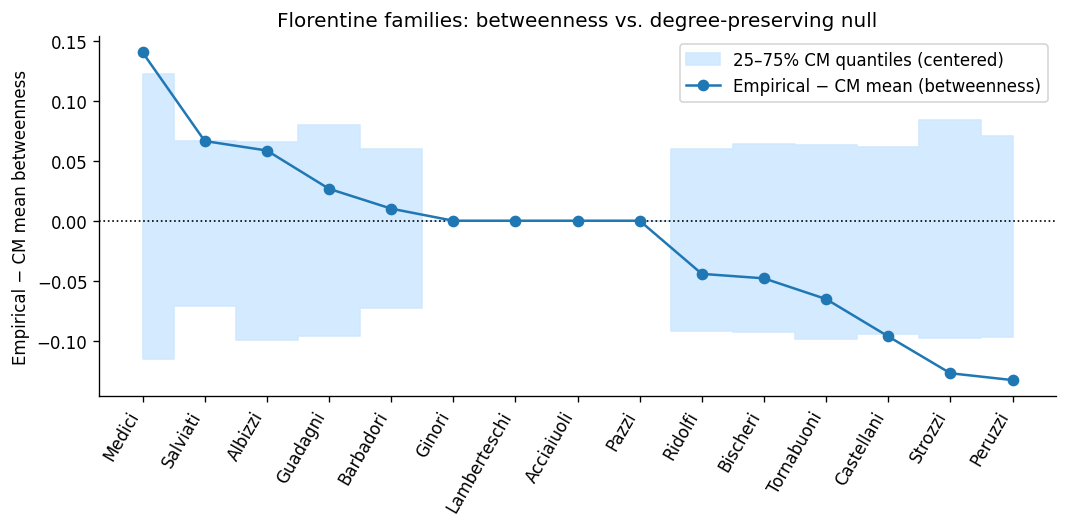

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

G = G_flor  # from above
deg_seq = [d for _, d in G.degree()]
nodes = list(G.nodes())
emp_bet = nx.betweenness_centrality(G, normalized=True)

R = 1000
bet_matrix = np.zeros((len(nodes), R), dtype=float)

for r in range(R):
    # Build config-model realization with *same degree sequence*:
    G_r = configuration_model(deg_seq, return_graph=True, seed=r)
    bet_r = nx.betweenness_centrality(G_r, normalized=True)
    # Map by node index since our configuration model labels nodes 0..N-1
    # We'll construct a mapping nodes[i] -> i for comparison. Re-label empirical G similarly:
    bet_matrix[:, r] = np.array([bet_r.get(i, 0.0) for i in range(len(nodes))])

# For fair comparison, relabel G to 0..N-1 and align emp_bet
mapping = {n: i for i, n in enumerate(nodes)}
G_ren = nx.relabel_nodes(G, mapping)
emp_bet_vec = np.array([emp_bet[nodes[i]] for i in range(len(nodes))])

# Compute means and quantiles
means = bet_matrix.mean(axis=1)
q25 = np.quantile(bet_matrix, 0.25, axis=1)
q75 = np.quantile(bet_matrix, 0.75, axis=1)
diff = emp_bet_vec - means

# Plot: difference from CM mean with IQR band (requested)
order = np.argsort(diff)[::-1]  # sort by biggest positive deviation
ordered_labels = [nodes[i] for i in order]

plt.figure(figsize=(9,4.5), dpi=120)
x = np.arange(len(nodes))
plt.fill_between(x, (q25 - means)[order], (q75 - means)[order], color="#cfe8ff", alpha=0.9,
                 step="mid", label="25–75% CM quantiles (centered)")
plt.axhline(0.0, color="k", linewidth=1, linestyle=":")
plt.plot(x, diff[order], marker="o", linewidth=1.5, color="#1f77b4",
         label="Empirical − CM mean (betweenness)")

plt.xticks(x, ordered_labels, rotation=60, ha="right")
plt.ylabel("Empirical − CM mean betweenness")
plt.title("Florentine families: betweenness vs. degree-preserving null")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()
